In [1]:
%cd notebooks

/app/data/EDGS/notebooks


In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
# Enable interactive mode
# %matplotlib ipympl
%matplotlib inline

import sys
import os
import random
sys.path.append("../")
sys.path.append("../submodules/gaussian-splatting")

from omegaconf import OmegaConf
import omegaconf
from hydra import initialize, compose
import hydra

from source.trainer import EDGSTrainer

In [2]:
with initialize(config_path="configs", version_base="1.1"):
    cfg = compose(config_name="visualize")
print(OmegaConf.to_yaml(cfg))


cfg.gs.dataset.model_path="/app/data/gs/EDGS/test_apr29_1"  # "change this to your path to the processed scene"
cfg.gs.dataset.source_path="/app/data/captures/test_apr29_1" # "change this to your path"
# Optionally for video processed
# cfg.gs.dataset.source_path="../assets/video_colmaped/"
cfg.gs.dataset.images="images"
cfg.gs.opt.TEST_CAM_IDX_TO_LOG=12 
cfg.train.gs_epochs=30000
cfg.gs.opt.opacity_reset_interval=1_000_000
cfg.train.no_densify=True
cfg.init_wC.matches_per_ref=15_000
cfg.init_wC.nns_per_ref=3
cfg.init_wC.num_refs=180
cfg.init_wC.roma_model="outdoors" 

omegaconf.OmegaConf.resolve(cfg)
gs = hydra.utils.instantiate(cfg.gs) 

gs:
  _target_: source.networks.Warper3DGS
  verbose: true
  viewpoint_stack: null
  sh_degree: 3
  opt:
    iterations: 30000
    position_lr_init: 0.00016
    position_lr_final: 1.6e-06
    position_lr_delay_mult: 0.01
    position_lr_max_steps: 30000
    feature_lr: 0.0025
    opacity_lr: 0.025
    scaling_lr: 0.005
    rotation_lr: 0.001
    percent_dense: 0.01
    lambda_dssim: 0.2
    densification_interval: 100
    opacity_reset_interval: 30000
    densify_from_iter: 500
    densify_until_iter: 15000
    densify_grad_threshold: 0.0002
    random_background: false
    save_iterations:
    - 3000
    - 7000
    - 15000
    - 30000
    batch_size: 64
    exposure_lr_init: 0.01
    exposure_lr_final: 0.0001
    exposure_lr_delay_steps: 0
    exposure_lr_delay_mult: 0.0
    TRAIN_CAM_IDX_TO_LOG: 50
    TEST_CAM_IDX_TO_LOG: 10
  pipe:
    convert_SHs_python: false
    compute_cov3D_python: false
    debug: false
    antialiasing: false
  dataset:
    densify_until_iter: 15000
    sour

In [ ]:
trainer = EDGSTrainer(GS=gs,
                      training_config=cfg.gs.opt,
                      device=cfg.device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /opt/conda/envs/edgs/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


In [12]:
trainer.load_ply("/app/data/gs/EDGS/test_apr29_1/point_cloud/iteration_15000/point_cloud.ply")

torch.Size([1, 2164, 1600])
(2164, 1600, 1)


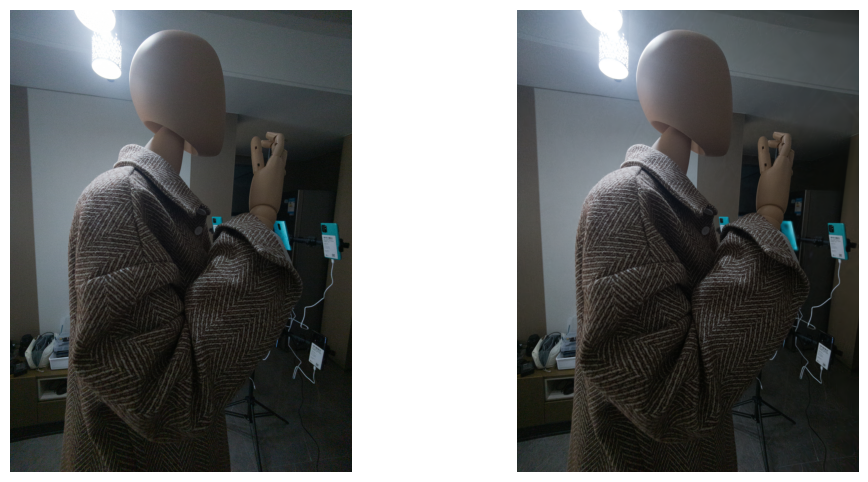

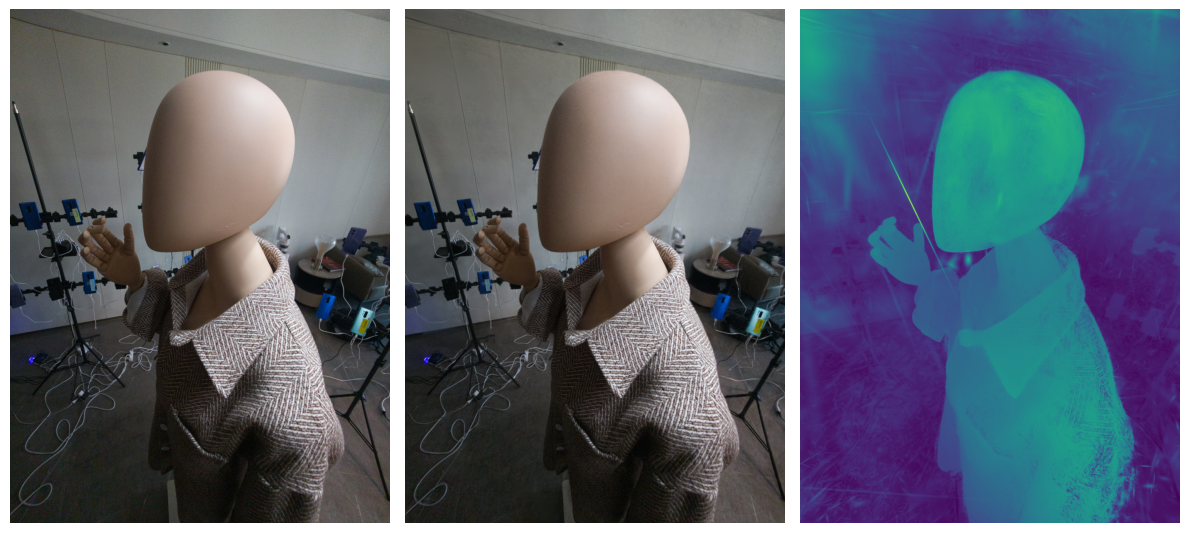

torch.Size([1, 2164, 1600])
(2164, 1600, 1)


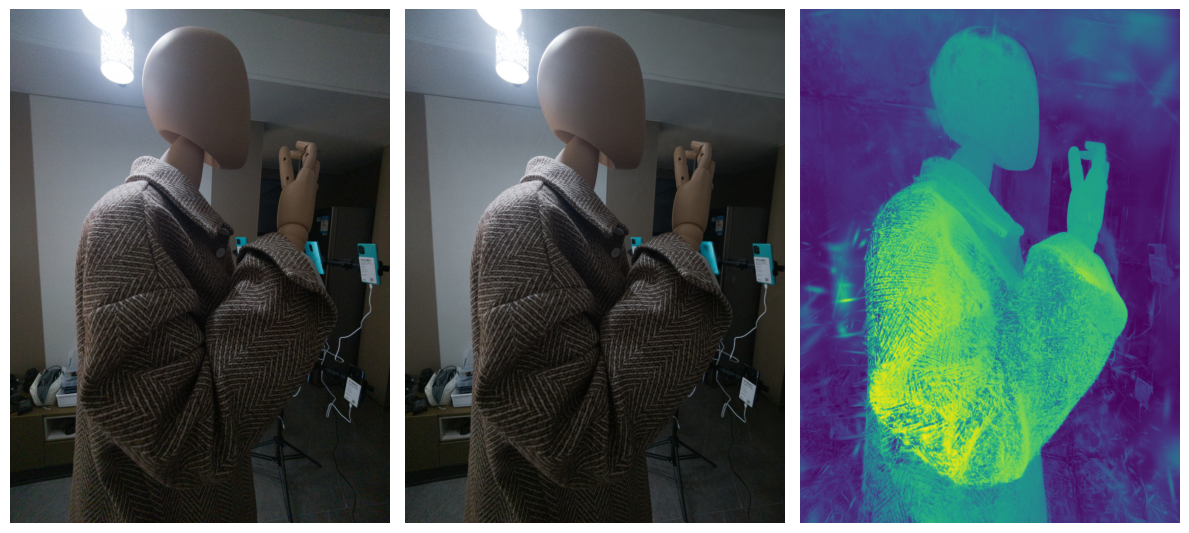

torch.Size([1, 2164, 1600])
(2164, 1600, 1)


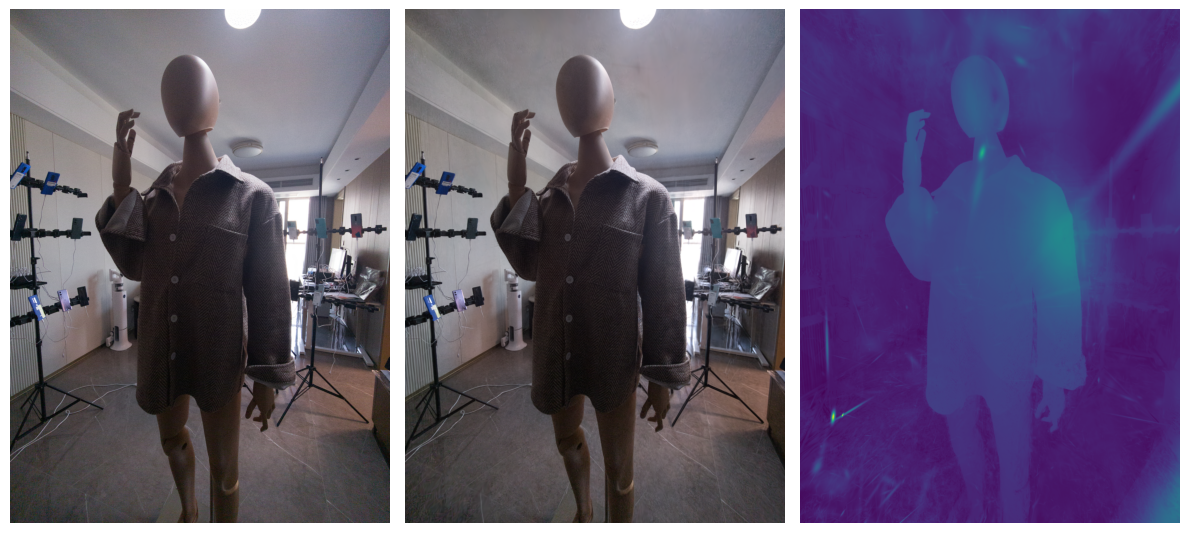

torch.Size([1, 2164, 1600])
(2164, 1600, 1)


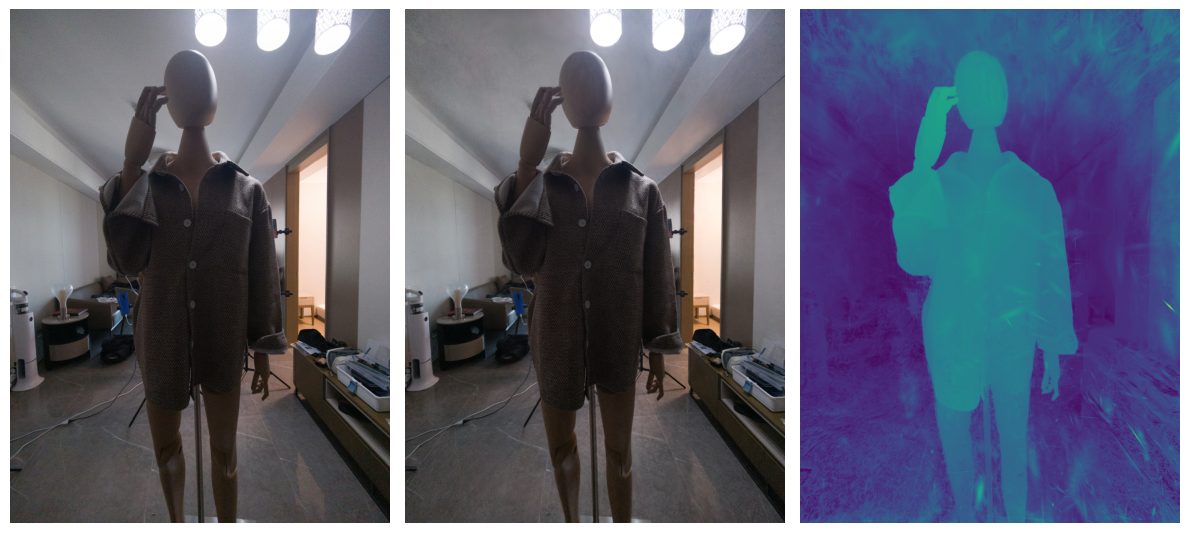

In [18]:
with torch.no_grad():
    viewpoint_stack = trainer.GS.scene.getTrainCameras()
    viewpoint_cams_to_viz = random.sample(trainer.GS.scene.getTrainCameras(), 4)
    for viewpoint_cam in viewpoint_cams_to_viz:
        render_pkg = trainer.GS(viewpoint_cam)
        image = render_pkg["render"]
        depth = render_pkg["depth"]
        print(depth.shape)
        
        image_np = image.clone().detach().cpu().numpy().transpose(1, 2, 0)
        depth_np = depth.clone().detach().cpu().numpy().transpose(1, 2, 0)
        image_gt_np = viewpoint_cam.original_image.clone().detach().cpu().numpy().transpose(1, 2, 0)

        print(depth_np.shape)
    
        # Clip values to be in the range [0, 1]
        image_np = np.clip(image_np*255, 0, 255).astype(np.uint8) 
        image_gt_np = np.clip(image_gt_np*255, 0, 255).astype(np.uint8)  
        depth_np = np.clip(depth_np*255, 0, 255).astype(np.uint8)  
    
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,6))
        ax[0].imshow(image_gt_np)
        ax[0].axis("off")
        ax[1].imshow(image_np)
        ax[1].axis("off")
        ax[2].imshow(depth_np)
        ax[2].axis("off")
        plt.tight_layout()
        plt.show()       